# Tutorial: Implementing BO through Scikit-Learn Gaussian Process

## Gaussian Process Surrogate

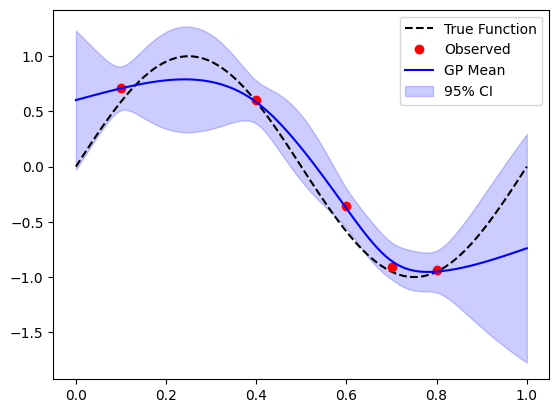

In [13]:
# type: ignore

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel

# Generate synthetic training data
X_train = np.array([0.1, 0.4, 0.6, 0.7, 0.8]).reshape(-1, 1)
y_train = np.sin(2 * np.pi * X_train).ravel() + np.random.normal(0, 0.1, X_train.shape[0])

# Define kernel: constant * RBF + Matern (as an example)
kernel = ConstantKernel(1.0) * RBF(length_scale=0.2) + Matern(length_scale=0.2, nu=1.5)

# Instantiate GP regressor
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1**2, n_restarts_optimizer=10)

# Fit to data
gp.fit(X_train, y_train)

# Predict at new points
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_pred, y_std = gp.predict(X_test, return_std=True)

# Plot results (optional)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(X_test, np.sin(2 * np.pi * X_test), 'k--', label='True Function')
plt.plot(X_train, y_train, 'ro', label='Observed')
plt.plot(X_test, y_pred, 'b-', label='GP Mean')
plt.fill_between(X_test.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, color='blue', alpha=0.2, label='95% CI')
plt.legend()
plt.show()

## Acquisition Functions

In [14]:
from scipy.stats import norm

def acq_ucb(x, gp, beta=2.0):
    """Upper Confidence Bound acquisition."""
    mu, std = gp.predict(x, return_std=True)
    return mu + beta * std

def acq_ei(x, gp, y_best, xi=0.0):
    """Expected Improvement acquisition."""
    mu, std = gp.predict(x, return_std=True)
    std = std.reshape(-1)
    mu = mu.reshape(-1)
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / std
        ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
        ei[std == 0.0] = 0.0
    return ei

def acq_pi(x, gp, y_best, xi=0.0):
    """Probability of Improvement acquisition."""
    mu, std = gp.predict(x, return_std=True)
    std = std.reshape(-1)
    mu = mu.reshape(-1)
    with np.errstate(divide='warn'):
        Z = (mu - y_best - xi) / std
        pi = norm.cdf(Z)
        pi[std == 0.0] = 0.0
    return pi

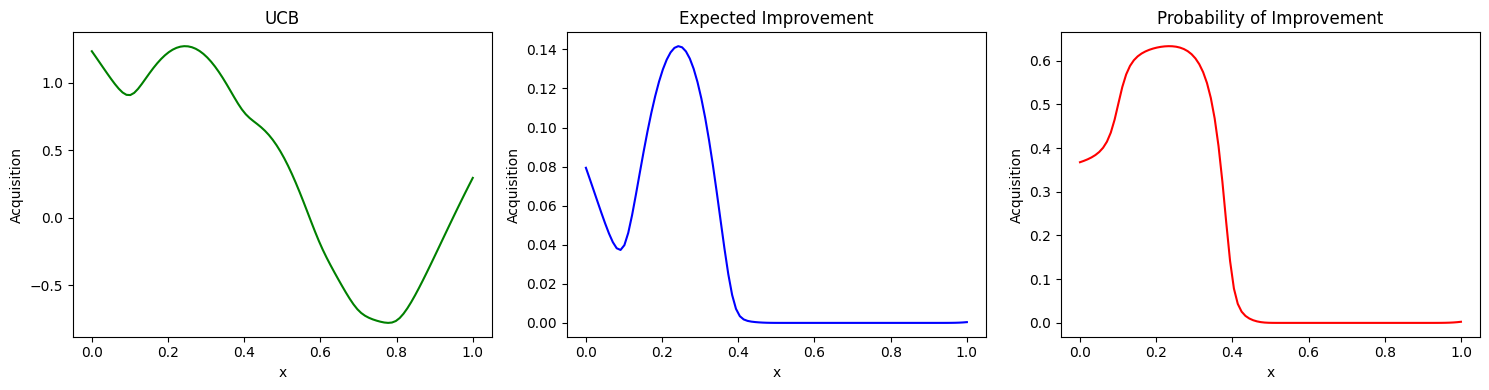

In [15]:
# Plot acquisition functions

y_best = np.max(y_train)

acq_ucb_vals = acq_ucb(X_test, gp)
acq_ei_vals = acq_ei(X_test, gp, y_best)
acq_pi_vals = acq_pi(X_test, gp, y_best)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(X_test, acq_ucb_vals, 'g-', label='UCB')
axes[0].set_title('UCB')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Acquisition')

axes[1].plot(X_test, acq_ei_vals, 'b-', label='EI')
axes[1].set_title('Expected Improvement')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Acquisition')

axes[2].plot(X_test, acq_pi_vals, 'r-', label='PI')
axes[2].set_title('Probability of Improvement')
axes[2].set_xlabel('x')
axes[2].set_ylabel('Acquisition')

plt.tight_layout()
plt.show()

# The Complete BO Workflow

We consider optimising a synthetic function over a two-dimensional design space:
$$
f(x_1, x_2) = \sin(5\pi x_1) \cos(5\pi x_2) + 0.5 \cos(10\pi x_1) \sin(10\pi x_2),
$$

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel

# ---------- Test objective (maximisation) ----------
def f_true(X):
    # X: shape (n_points, 2)
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.sin(5 * np.pi * x1) * np.cos(5 * np.pi * x2) + \
           0.5 * np.cos(10 * np.pi * x1) * np.sin(10 * np.pi * x2)

# ---------- Initialisation ----------
n_init = 5
X_init = np.random.uniform(0, 1, (n_init, 2))
y_init = f_true(X_init).ravel()

X = X_init.copy()
y = y_init.copy()

# --------- The Grid for Acquisition -----------
grid_size = 100   # grid density per dimension for acquisition maximisation
x1_grid = np.linspace(0, 1, grid_size)
x2_grid = np.linspace(0, 1, grid_size)
X_mesh = np.array(np.meshgrid(x1_grid, x2_grid)).reshape(2, -1).T  # shape (grid_size**2, 2)

# ---------- BO loop ----------
for t in range(20):  # A fixed number of iterations after initialisation
    # Fit GP
    kernel = ConstantKernel(1.0) * Matern(length_scale=0.2, nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)
    gp.fit(X, y)

    # Maximise UCB on the 2D grid
    ucb = acq_ucb(X_mesh, gp, beta=2.0)  # Previously defined acquisition function
    x_next = X_mesh[np.argmax(ucb)].reshape(1, -1)

    # Evaluate true function
    y_next = f_true(x_next).ravel()

    # Update data
    X = np.vstack([X, x_next])
    y = np.hstack([y, y_next])

    # Optional: print progress
    best_y = np.max(y)
    print(f"Iter {t+1}: selected x = {x_next[0,0]:.4f},{x_next[0,1]:.4f}, y = {y_next[0]:.4f}, best so far = {best_y:.4f}")

# ---------- Final recommendation ----------
best_idx = np.argmax(y)
x_best = X[best_idx]
y_best = y[best_idx]
print(f"\nBest found: x = [{x_best[0]:.4f}, {x_best[1]:.4f}], y = {y_best:.4f}")

Iter 1: selected x = 1.0000,1.0000, y = -0.0000, best so far = 1.0377
Iter 2: selected x = 0.0000,0.0000, y = 0.0000, best so far = 1.0377
Iter 3: selected x = 0.7071,0.9899, y = 1.1335, best so far = 1.1335


C:\Users\10340\AppData\Roaming\Python\Python312\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Iter 4: selected x = 0.4747,1.0000, y = -0.9224, best so far = 1.1335
Iter 5: selected x = 0.6768,0.9495, y = 1.0279, best so far = 1.1335
Iter 6: selected x = 0.6566,1.0000, y = 0.7761, best so far = 1.1335
Iter 7: selected x = 0.7071,0.8687, y = -0.8754, best so far = 1.1335
Iter 8: selected x = 0.7576,1.0000, y = 0.6182, best so far = 1.1335
Iter 9: selected x = 0.6970,0.9697, y = 1.2933, best so far = 1.2933
Iter 10: selected x = 0.6869,0.9798, y = 1.2015, best so far = 1.2933
Iter 11: selected x = 0.7071,0.9596, y = 1.2660, best so far = 1.2933
Iter 12: selected x = 0.1515,0.6061, y = -0.6825, best so far = 1.2933
Iter 13: selected x = 0.2929,0.7071, y = -0.0027, best so far = 1.2933
Iter 14: selected x = 0.7071,0.9697, y = 1.2806, best so far = 1.2933
Iter 15: selected x = 0.6970,0.9596, y = 1.2796, best so far = 1.2933
Iter 16: selected x = 0.1818,0.7576, y = -0.1873, best so far = 1.2933
Iter 17: selected x = 0.6970,0.9697, y = 1.2933, best so far = 1.2933
Iter 18: selected x =

C:\Users\10340\AppData\Roaming\Python\Python312\site-packages\sklearn\gaussian_process\_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
